### Import Dependencies

In [1]:
from pydantic import BaseModel

from langsmith import traceable, get_current_run_tree

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send

from langchain_core.messages import SystemMessage
from IPython.display import Image, display

from typing import Literal, Dict, Any, Annotated, List
from operator import add

import random
import openai
import pandas as pd

from jinja2 import Template

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

In [3]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding


def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context




In [4]:
qdrant_client = QdrantClient(url="http://127.0.0.1:6333")


In [5]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

In [6]:
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [7]:
query = "Name me a good summer song"

In [8]:
answer = retrieve_data(query, qdrant_client, k=10)

In [9]:
answer

{'retrieved_context_ids': ['B09XGWCB4B',
  'B09XGWCB4B',
  'B09Y4X2XTS',
  'B09Y4X2XTS',
  'B0BV5WY5TC',
  'B0C1SWKV9J',
  'B0BXPRDBVN',
  'B09NFQ6593',
  'B09NFQ6593',
  'B0C1SWKV9J'],
 'retrieved_context': ['Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] ',
  'Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] ',
  'Songs About You ',
  'Songs About You ',
  'That! Feels Good![LP] ',
  'Stick Season       Explicit Lyrics ',
  'Life Is Like A Song[LP] ',
  'Summer Of Soul ...Or, When The Revolution Could Not Be Televised Soundtrack ',
  'Summer Of Soul ...Or, When The Revolution Could Not Be Televised Soundtrack ',
  'Stick Season       Explicit Lyrics '],
 'similarity_scores': [0.8500001,
  0.690909,
  0.5833333,
  0.5054945,
  0.5,
  0.37500003,
  0.36250004,
  0.3611111,
  0.35576925,
  0.33333334],
 'retrieved_context_ratings': [4.7,
  4.7,
  4.8,
  4.8,
  4.7,
  4.7,
  4.6,
  4.5,
  4.5,
  4.7]}

### Multi-intent Questions

In [10]:
query = "Name me a good summer song and a road trip album for the family"

In [11]:
answer = retrieve_data(query, qdrant_client, k=10)

In [12]:
answer

{'retrieved_context_ids': ['B09XGWCB4B',
  'B09XGWCB4B',
  'B0C1SWKV9J',
  'B09ZKF44MH',
  'B0C1SWKV9J',
  'B0BL8VCTKK',
  'B0BL8VCTKK',
  'B09ZKF44MH',
  'B09NFQ6593',
  'B09TPQJW15'],
 'retrieved_context': ['Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] ',
  'Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] ',
  'Stick Season       Explicit Lyrics ',
  'BTS Proof Anthology Album Compact Edition Contents+1p Folding Poster On Pack+Tracking Sealed 📆Release Date : 2022.06.10 [Albums will be shipped sequentially after the release date.] 🎁FREE GIFT : BTS 4pcs of Double-sided Photocards Set + Lenticular + Transperant Photocard + Sticker (KPOP MARKET Store Gift)🎁 📌100% Original Brand New Item. Sales volume is reflected in the HANTEO and GAON Charts. 🎁 Safe packaging with traceable delivery 🎈KPOP MARKET (HANTEO & GAON Chart Family Shop) will ship your order from South Korea.',
  'Stick Season       Explicit Lyrics ',
  'Stoned Cold Country ',
  'Stoned Cold Countr

In [13]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [14]:
def query_expansion_node(query) -> dict:

    prompt_template = """You are a query expansion module in a music catalogue assistant. Your job is to rewrite a customer's query into distinct statements for semantic music search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate album, song, artist, or attribute from the query.
- Use natural music catalogue description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Name me a good summer song and a relaxing jazz album"
Statements:
- "Upbeat summer song"
- "Relaxing jazz album"

Question: "What's a good road trip album for the family?"
Statements:
- "Family-friendly road trip album"

Question: "Do you have any Queen albums?"
Statements:
- "Queen albums"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "queries": response.statements
    }

In [15]:
answer = query_expansion_node(query)

In [16]:
answer

{'queries': ['Upbeat summer song', 'Family-friendly road trip album']}

## LangGraph

### Query Expansion (Sequential Execution)

In [17]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

### Query Expansion / Rewriting Node

In [18]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [19]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state) -> dict:  # no State needed

    prompt_template = """You are a query expansion module in a music catalogue assistant. Your job is to rewrite a customer's query into distinct statements for semantic music search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate album, song, artist, or attribute from the query.
- Use natural music catalogue description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Name me a good summer song and a relaxing jazz album"
Statements:
- "Upbeat summer song"
- "Relaxing jazz album"

Question: "What's a good road trip album for the family?"
Statements:
- "Family-friendly road trip album"

Question: "Do you have any Queen albums?"
Statements:
- "Queen albums"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [20]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://127.0.0.1:6333")

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }

### Aggregator Node

In [21]:
class AggregatorResponse(BaseModel):
    answer: str

In [22]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a music catalogue assistant that can answer questions about albums, songs, and formats in the catalogue.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available music.
- The answer should contain detailed information about each item with artist, format, and key details in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [23]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

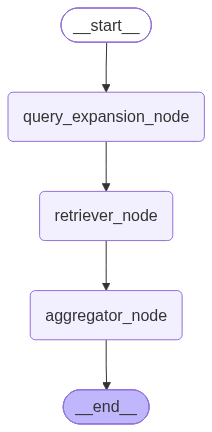

In [24]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
query = "Name me a good summer song and a road trip album for the family"

In [26]:
initial_state = {
    "initial_query": query
}

In [27]:
result = graph.invoke(initial_state)

In [28]:
result

{'expanded_query': ['Good summer song', 'Family-friendly road trip album'],
 'retrieved_context': ['- ID: B09XGWCB4B, rating: 4.7, description: Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] \n- ID: B09XGWCB4B, rating: 4.7, description: Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] \n- ID: B0C1SWKV9J, rating: 4.7, description: Stick Season       Explicit Lyrics \n- ID: B0BV5WY5TC, rating: 4.7, description: That! Feels Good![LP] \n- ID: B09Y4X2XTS, rating: 4.8, description: Songs About You \n',
  '- ID: B09TG4Q9RF, rating: 4.8, description: Traveller \n- ID: B0BBMSLPDG, rating: 4.8, description: A Family Christmas \n- ID: B09TG4Q9RF, rating: 4.8, description: Traveller \n- ID: B0BBMSLPDG, rating: 4.8, description: A Family Christmas \n- ID: B09ZKF44MH, rating: 4.7, description: BTS Proof Anthology Album Compact Edition Contents+1p Folding Poster On Pack+Tracking Sealed 📆Release Date : 2022.06.10 [Albums will be shipped sequentially after the release date.]

In [29]:
print(result["answer"])

- **Summer song:** *Sounds Of Summer: The Very Best Of The Beach Boys* — by **The Beach Boys**, available as a **remastered** release. This is a strong summer pick based on the available music.
- **Road trip album for the family:** *Traveller* — by **Chris Stapleton**, available as an album in the available music. It’s a good family road trip choice.

Other family-friendly album option from the available music:
- *A Family Christmas* — by **The Piano Guys**, an album that fits a family listening setting.


### Query Expansion (Parallel Execution)

In [30]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

### Query Expansion / Rewriting Node

In [31]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [32]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:

    prompt_template = """You are a query expansion module in a music catalogue assistant. Your job is to rewrite a customer's query into distinct statements for semantic music search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate album, song, artist, or attribute from the query.
- Use natural music catalogue description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Name me a good summer song and a relaxing jazz album"
Statements:
- "Upbeat summer song"
- "Relaxing jazz album"

Question: "What's a good road trip album for the family?"
Statements:
- "Family-friendly road trip album"

Question: "Do you have any Queen albums?"
Statements:
- "Queen albums"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpandResponse
    )

    return {
        "expanded_query": response.statements
    }

In [33]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

### Retriever Node

In [34]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    hybrid = True

    qdrant_client = QdrantClient(url="http://127.0.0.1:6333")

    query_embedding = get_embedding(state["query"])

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=state["k"]
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Aggregator Node

In [35]:
class AggregatorResponse(BaseModel):
    answer: str

In [36]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a music catalogue assistant that can answer questions about albums, songs, and formats in the catalogue.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available music.
- The answer should contain detailed information about each item with artist, format, and key details in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context=preprocessed_context,
        question=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [37]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

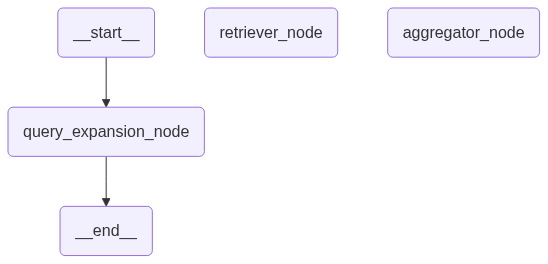

In [38]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
query = "Name me a good summer song and a road trip album for the family"

In [40]:
initial_state = {
    "initial_query": query
}

In [41]:
result = graph.invoke(initial_state)

In [42]:
result

{'expanded_query': ['Good summer song', 'Family-friendly road trip album'],
 'retrieved_context': ['- ID: B09XGWCB4B, rating: 4.7, description: Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] \n- ID: B09XGWCB4B, rating: 4.7, description: Sounds Of Summer: The Very Best Of The Beach Boys[Remastered] \n- ID: B09ZKF44MH, rating: 4.7, description: BTS Proof Anthology Album Compact Edition Contents+1p Folding Poster On Pack+Tracking Sealed 📆Release Date : 2022.06.10 [Albums will be shipped sequentially after the release date.] 🎁FREE GIFT : BTS 4pcs of Double-sided Photocards Set + Lenticular + Transperant Photocard + Sticker (KPOP MARKET Store Gift)🎁 📌100% Original Brand New Item. Sales volume is reflected in the HANTEO and GAON Charts. 🎁 Safe packaging with traceable delivery 🎈KPOP MARKET (HANTEO & GAON Chart Family Shop) will ship your order from South Korea.\n- ID: B0C1SWKV9J, rating: 4.7, description: Stick Season       Explicit Lyrics \n- ID: B0C1SWKV9J, rating: 4.7, desc

In [43]:
print(result["answer"])

- Good summer song: **The Beach Boys – Sounds Of Summer: The Very Best Of The Beach Boys [Remastered]** (format not specified in the available music). It’s a strong summer pick from the available music, and it has a **4.7 rating**.
- Road trip album for the family: **The Beatles?** Not available in the provided music. Based on the available music, a better family-friendly road trip choice is **A Family Christmas** (format not specified in the available music), with a **4.8 rating**. If you want a road-oriented pick from the available music, **Road (Black 2LP/180g + DVD)** is the most directly road-themed option, also rated **4.8**.
